In [10]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# 1. Charger les métadonnées
metadata_path = "../data/raw/melanoma/HAM10000_metadata.csv"
df_meta = pd.read_csv(metadata_path)

# 2. Re-créer le dictionnaire des chemins d'images (part_1 et part_2)
image_paths = {
    os.path.splitext(img)[0]: os.path.join("../data/raw/melanoma/HAM10000_images_part_1", img) 
    for img in os.listdir("../data/raw/melanoma/HAM10000_images_part_1")
}
image_paths.update({
    os.path.splitext(img)[0]: os.path.join("../data/raw/melanoma/HAM10000_images_part_2", img) 
    for img in os.listdir("../data/raw/melanoma/HAM10000_images_part_2")
})

# Associer chaque image à son chemin absolu/relatif
df_meta['path'] = df_meta['image_id'].map(image_paths)

# 3. Séparation Train / Validation (80% / 20%) de façon stratifiée pour garder les proportions de classes
train_df, val_df = train_test_split(df_meta, test_size=0.2, random_state=42, stratify=df_meta['dx'])

print(f"Nombre d'images pour l'entraînement : {len(train_df)}")
print(f"Nombre d'images pour la validation : {len(val_df)}")

# 4. Paramètres de l'image
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Générateurs d'images avec normalisation (rescale 1./255)
train_datagen = ImageDataGenerator(rescale=1./255.0)
val_datagen = ImageDataGenerator(rescale=1./255.0)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Nombre d'images pour l'entraînement : 8012
Nombre d'images pour la validation : 2003
Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Définition de l'architecture CNN
model = Sequential([
    # Première couche de convolution
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    
    # Deuxième couche de convolution
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Troisième couche de convolution
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Aplatissement pour passer aux couches denses
    Flatten(),
    
    # Couche dense fully-connected
    Dense(128, activation='relu'),
    Dropout(0.5), # Pour éviter le surapprentissage (overfitting)
    
    # Couche de sortie avec 7 classes et activation softmax
    Dense(7, activation='softmax')
])

# 2. Compilation du modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Afficher le résumé de l'architecture
model.summary()

/home/yassine/MedRoute-AI/medroute/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789724763.770476  111192 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Définition du nombre d'époques pour un premier test
EPOCHS = 5

# Lancement de l'entraînement avec les générateurs
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/5


I0000 00:00:1789725131.428028  111192 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


251/251 ━━━━━━━━━━━━━━━━━━━━ 111s 437ms/step - accuracy: 0.6644 - loss: 1.0327 - val_accuracy: 0.6695 - val_loss: 0.8907
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 365ms/step - accuracy: 0.6670 - loss: 0.9244 - val_accuracy: 0.6740 - val_loss: 0.8398
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 366ms/step - accuracy: 0.6766 - loss: 0.8908 - val_accuracy: 0.6720 - val_loss: 0.8751
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 98s 389ms/step - accuracy: 0.6787 - loss: 0.8677 - val_accuracy: 0.6805 - val_loss: 0.8413
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 93s 369ms/step - accuracy: 0.6921 - loss: 0.8165 - val_accuracy: 0.7049 - val_loss: 0.7991


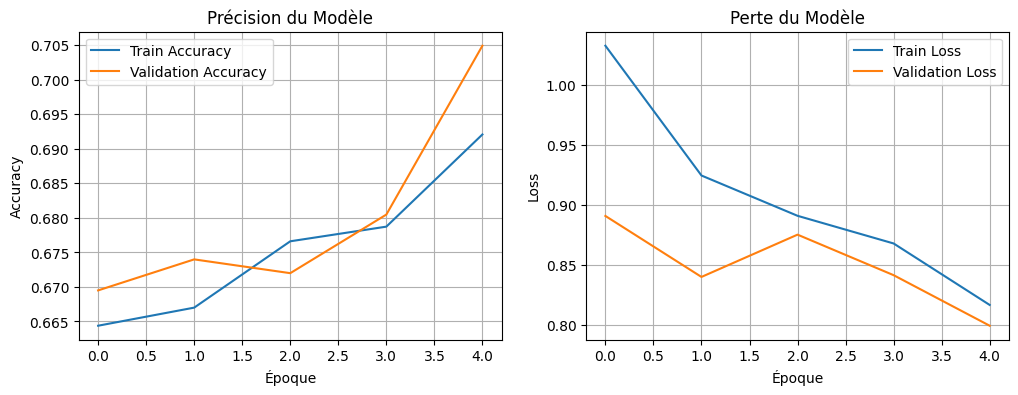

In [4]:
import matplotlib.pyplot as plt

# Tracé de la précision
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Précision du Modèle')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Tracé de la perte (loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Perte du Modèle')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [5]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcul des poids pour chaque classe en fonction de leur rareté
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['dx']),
    y=train_df['dx']
)

# Création du dictionnaire de correspondance
class_weights_dict = dict(enumerate(class_weights))
print("Poids des classes calculés :", class_weights_dict)

Poids des classes calculés : {0: np.float64(4.368593238822246), 1: np.float64(2.7848453249913105), 2: np.float64(1.3021290427433772), 3: np.float64(12.440993788819876), 4: np.float64(1.2860353130016051), 5: np.float64(0.21338020666879728), 6: np.float64(10.040100250626567)}


In [6]:
# Définition d'un nombre d'époques plus élevé pour laisser le temps au modèle d'apprendre
EPOCHS = 15

# Lancement de l'entraînement avec prise en compte du déséquilibre
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights_dict
)

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 89s 352ms/step - accuracy: 0.4465 - loss: 1.7387 - val_accuracy: 0.2092 - val_loss: 1.8330
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 93s 371ms/step - accuracy: 0.4264 - loss: 1.6125 - val_accuracy: 0.5597 - val_loss: 1.0882
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 365ms/step - accuracy: 0.4758 - loss: 1.4447 - val_accuracy: 0.4264 - val_loss: 1.4254
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 104s 415ms/step - accuracy: 0.4563 - loss: 1.4083 - val_accuracy: 0.4968 - val_loss: 1.2527
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 91s 361ms/step - accuracy: 0.5037 - loss: 1.2951 - val_accuracy: 0.5477 - val_loss: 1.0895
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 94s 372ms/step - accuracy: 0.5140 - loss: 1.2222 - val_accuracy: 0.4983 - val_loss: 1.2025
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 367ms/step - accuracy: 0.5286 - loss: 1.1572 - val_accuracy: 0.5227 - val_loss: 1.1187
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 93s 372ms/step - accuracy: 0.5221 - loss: 

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 201ms/step
Rapport de classification :
              precision    recall  f1-score   support

           0       0.22      0.32      0.26        65
           1       0.32      0.53      0.40       103
           2       0.34      0.50      0.41       220
           3       0.12      0.39      0.18        23
           4       0.29      0.55      0.38       223
           5       0.95      0.60      0.73      1341
           6       0.30      0.75      0.43        28

    accuracy                           0.57      2003
   macro avg       0.36      0.52      0.40      2003
weighted avg       0.73      0.57      0.61      2003



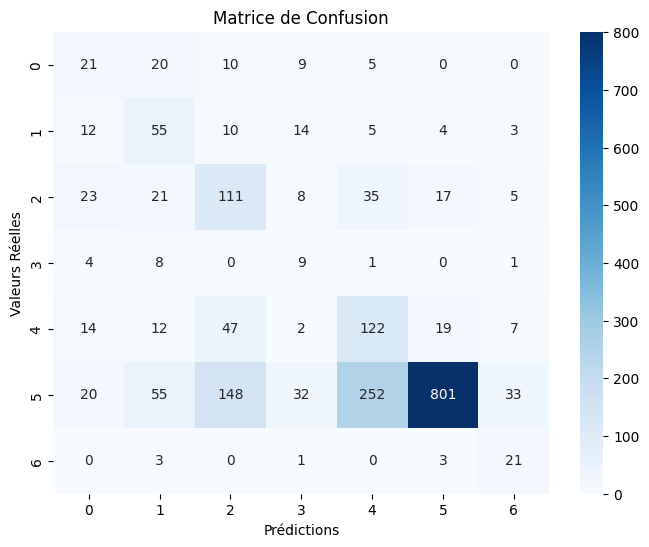

In [7]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Générer les prédictions sur le jeu de validation
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# 2. Afficher le rapport de classification détaillé par classe
print("Rapport de classification :")
print(classification_report(y_true, y_pred))

# 3. Tracer la matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs Réelles')
plt.show()

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# 1. Charger MobileNetV2 pré-entraîné sur ImageNet, sans sa couche de classification (include_top=False)
# On fixe la taille de nos images (par exemple 224x224 avec 3 canaux RGB)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Geler le modèle de base pour ne pas modifier les poids pré-entraînés lors des premières époques
base_model.trainable = False

# 3. Ajouter nos propres couches personnalisées par-dessus
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)  # Pour éviter le surapprentissage (overfitting)

# Couche de sortie avec 7 neurones (un par classe) et une activation softmax
predictions = Dense(7, activation='softmax')(x)

# 4. Assembler le nouveau modèle final
model_transfer = Model(inputs=base_model.input, outputs=predictions)

# 5. Compiler le modèle
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_transfer.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
# Définition du nombre d'époques (par exemple 10 pour commencer)
EPOCHS_TRANSFER = 10

# Lancement de l'entraînement du modèle avec transfer learning
history_transfer = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_TRANSFER,
    class_weight=class_weights_dict
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 159s 618ms/step - accuracy: 0.2449 - loss: 1.9681 - val_accuracy: 0.3964 - val_loss: 1.6393
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 154s 613ms/step - accuracy: 0.3692 - loss: 1.6274 - val_accuracy: 0.4688 - val_loss: 1.5041
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 159s 633ms/step - accuracy: 0.4386 - loss: 1.4825 - val_accuracy: 0.5637 - val_loss: 1.2920
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 160s 636ms/step - accuracy: 0.4672 - loss: 1.4084 - val_accuracy: 0.5272 - val_loss: 1.3359
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 170s 676ms/step - accuracy: 0.4954 - loss: 1.3387 - val_accuracy: 0.5202 - val_loss: 1.3272
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 157s 624ms/step - accuracy: 0.5019 - loss: 1.3005 - val_accuracy: 0.5647 - val_loss: 1.2136
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 169s 674ms/step - accuracy: 0.5263 - loss: 1.2104 - val_accuracy: 0.5916 - val_loss: 1.1435
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 161s 641ms/step - accuracy: 0.5442 -

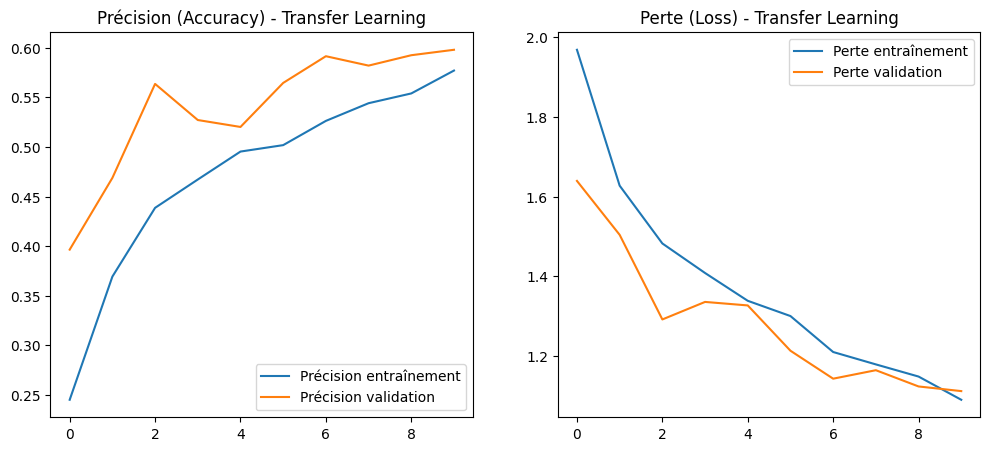

In [14]:
import matplotlib.pyplot as plt

# Récupération des données d'historique
acc = history_transfer.history['accuracy']
val_acc = history_transfer.history['val_accuracy']
loss = history_transfer.history['loss']
val_loss = history_transfer.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Graphique de la précision
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Précision entraînement')
plt.plot(epochs_range, val_acc, label='Précision validation')
plt.legend(loc='lower right')
plt.title('Précision (Accuracy) - Transfer Learning')

# Graphique de la perte (loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perte entraînement')
plt.plot(epochs_range, val_loss, label='Perte validation')
plt.legend(loc='upper right')
plt.title('Perte (Loss) - Transfer Learning')

plt.show()

In [16]:
# 1. On dégèle la base du modèle (que l'on suppose avoir été stockée dans la variable base_model)
base_model.trainable = True

# On choisit de ne dégeler que les 30 dernières couches pour le fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 2. Recompilation du modèle avec un taux d'apprentissage très faible (learning rate)
from tensorflow.keras.optimizers import Adam

model_transfer.compile(
    optimizer=Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',     
    metrics=['accuracy']
)

print("Modèle prêt pour le Fine-Tuning !")

Modèle prêt pour le Fine-Tuning !


In [17]:
EPOCHS_FINETUNE = 10

history_finetune = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weights_dict
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 194s 745ms/step - accuracy: 0.4199 - loss: 1.5450 - val_accuracy: 0.6016 - val_loss: 1.1221
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 197s 785ms/step - accuracy: 0.4699 - loss: 1.3101 - val_accuracy: 0.6131 - val_loss: 1.1037
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 206s 822ms/step - accuracy: 0.5081 - loss: 1.2077 - val_accuracy: 0.6176 - val_loss: 1.0879
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 216s 859ms/step - accuracy: 0.5447 - loss: 1.0708 - val_accuracy: 0.6206 - val_loss: 1.0647
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 209s 832ms/step - accuracy: 0.5763 - loss: 1.0006 - val_accuracy: 0.6281 - val_loss: 1.0368
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 192s 766ms/step - accuracy: 0.6001 - loss: 0.9252 - val_accuracy: 0.6321 - val_loss: 1.0338
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 200s 796ms/step - accuracy: 0.6192 - loss: 0.8675 - val_accuracy: 0.6395 - val_loss: 1.0037
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 197s 784ms/step - accuracy: 0.6253 -

63/63 ━━━━━━━━━━━━━━━━━━━━ 39s 577ms/step
--- Rapport de Classification ---
              precision    recall  f1-score   support

       akiec       0.31      0.55      0.40        65
         bcc       0.37      0.73      0.49       103
         bkl       0.45      0.45      0.45       220
          df       0.19      0.57      0.28        23
         mel       0.35      0.53      0.42       223
          nv       0.94      0.72      0.81      1341
        vasc       0.46      0.61      0.52        28

    accuracy                           0.66      2003
   macro avg       0.44      0.59      0.48      2003
weighted avg       0.76      0.66      0.69      2003



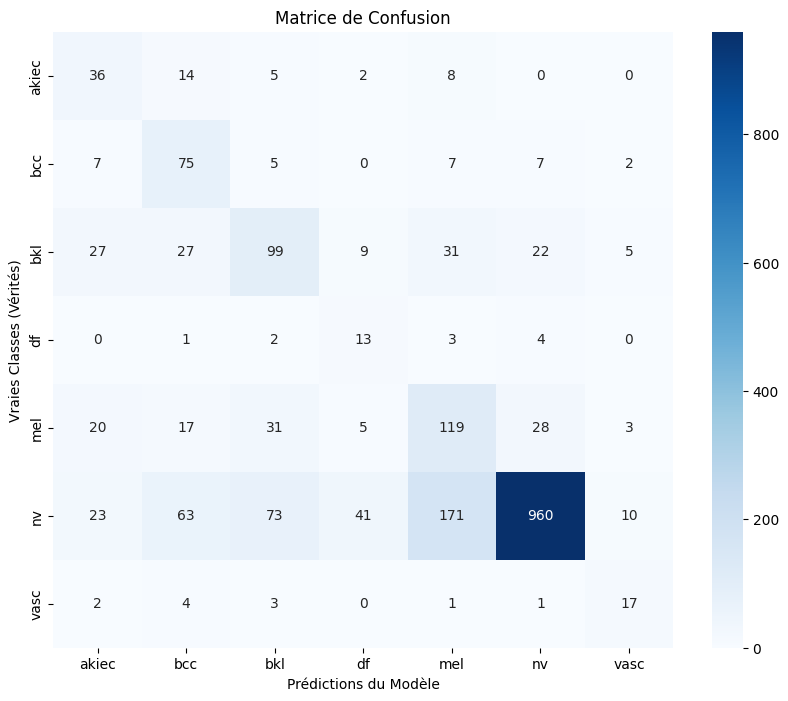

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Récupérer les prédictions du modèle sur le générateur de validation
# (On s'assure de réinitialiser le générateur pour être aligné)
val_generator.reset()
Y_pred = model_transfer.predict(val_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)

# 2. Récupérer les vraies étiquettes (true labels) du générateur de validation
y_true = val_generator.classes

# 3. Récupérer les noms des classes
class_labels = list(val_generator.class_indices.keys())

# 4. Afficher le rapport de classification détaillé (Precision, Recall, F1-score par classe)
print("--- Rapport de Classification ---")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# 5. Créer et afficher la matrice de confusion
conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Prédictions du Modèle')
plt.ylabel('Vraies Classes (Vérités)')
plt.title('Matrice de Confusion')
plt.show()

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Générateur d'entraînement renforcé avec des transformations
train_datagen = ImageDataGenerator(
    rescale=1./255.0,
    rotation_range=20,      # Légères rotations
    width_shift_range=0.1,  # Décalages horizontaux
    height_shift_range=0.1, # Décalages verticaux
    shear_range=0.1,        # Cisaillement
    zoom_range=0.1,         # Zooms
    horizontal_flip=True,   # Effet miroir horizontal
    vertical_flip=True      # Effet miroir vertical (utile en imagerie médicale)
)

# Le générateur de validation garde uniquement le rescale (pas de triche !)
val_datagen = ImageDataGenerator(rescale=1./255.0)

# Recréation des générateurs avec les DataFrames (garde tes chemins et variables d'origine)
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='dx',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='dx',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Très important de garder False pour l'évaluation et la matrice de confusion
)

Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [20]:
# On s'assure que la base est totalement modifiable
base_model.trainable = True

# On gèle tout sauf les 60 dernières couches du modèle de base
for layer in base_model.layers[:-60]:
    layer.trainable = False

# Recompilation avec un learning rate toujours très prudent
from tensorflow.keras.optimizers import Adam

model_transfer.compile(
    optimizer=Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',     
    metrics=['accuracy']
)

print("Modèle prêt pour un Fine-Tuning approfondi !")

Modèle prêt pour un Fine-Tuning approfondi !


In [21]:
EPOCHS_DEEP_FT = 15

history_deep_ft = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_DEEP_FT,
    class_weight=class_weights_dict
)

Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 306s 1s/step - accuracy: 0.6011 - loss: 1.1018 - val_accuracy: 0.6540 - val_loss: 0.9390
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.5806 - loss: 1.0217 - val_accuracy: 0.6430 - val_loss: 0.9655
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 301s 1s/step - accuracy: 0.5840 - loss: 1.0116 - val_accuracy: 0.6360 - val_loss: 0.9793
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - accuracy: 0.5927 - loss: 0.9683 - val_accuracy: 0.6291 - val_loss: 0.9783
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 282s 1s/step - accuracy: 0.5959 - loss: 0.9444 - val_accuracy: 0.6331 - val_loss: 0.9631
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.6010 - loss: 0.9209 - val_accuracy: 0.6286 - val_loss: 0.9685
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.6077 - loss: 0.9165 - val_accuracy: 0.6131 - val_loss: 1.0064
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 421s 2s/step - accuracy: 0.6166 - loss: 0.8911 - val_accu

63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 483ms/step
--- Rapport de Classification ---
              precision    recall  f1-score   support

       akiec       0.58      0.51      0.54        65
         bcc       0.50      0.67      0.57       103
         bkl       0.42      0.64      0.50       220
          df       0.15      0.74      0.26        23
         mel       0.32      0.61      0.42       223
          nv       0.97      0.64      0.77      1341
        vasc       0.42      0.79      0.54        28

    accuracy                           0.63      2003
   macro avg       0.48      0.65      0.51      2003
weighted avg       0.78      0.63      0.67      2003



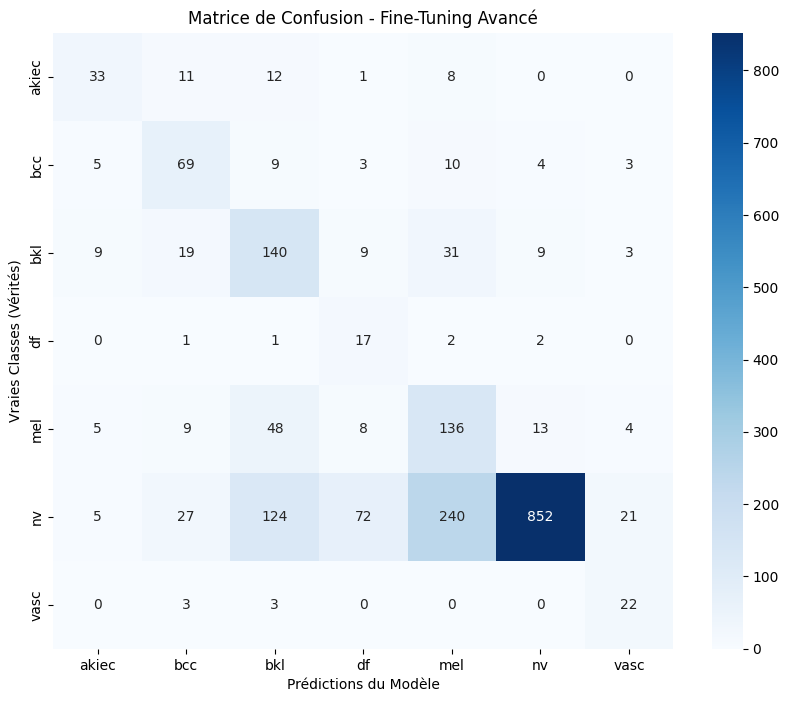

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Récupérer les prédictions du modèle sur le générateur de validation
val_generator.reset()
Y_pred = model_transfer.predict(val_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)

# 2. Récupérer les vraies étiquettes du générateur de validation
y_true = val_generator.classes

# 3. Récupérer les noms des classes
class_labels = list(val_generator.class_indices.keys())

# 4. Afficher le rapport de classification détaillé
print("--- Rapport de Classification ---")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# 5. Créer et afficher la matrice de confusion
conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Prédictions du Modèle')
plt.ylabel('Vraies Classes (Vérités)')
plt.title('Matrice de Confusion - Fine-Tuning Avancé')
plt.show()

In [23]:
model_transfer.save('medroute_melanoma_model.h5')
print("Modèle sauvegardé avec succès !")

Modèle sauvegardé avec succès !


In [33]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_skin_lesion(img_path, model, class_labels):
    """
    Fonction pour prédire la classe d'une lésion cutanée à partir d'une image unique.
    """
    # 1. Charger et redimensionner l'image au format attendu par MobileNetV2 (224x224)
    img = image.load_img(img_path, target_size=(224, 224))
    
    # 2. Convertir l'image en tableau numpy et ajouter une dimension pour le batch
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    
    # 3. Normaliser l'image (comme on l'a fait avec rescale=1./255.0 dans les générateurs)
    x = x / 255.0
    
    # 4. Effectuer la prédiction
    predictions = model.predict(x)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100
    
    # 5. Récupérer le nom de la classe prédite
    predicted_class_name = class_labels[predicted_class_idx]
    
    # Affichage des résultats
    print(f"--- Résultat de l'analyse MedRoute AI ---")
    print(f"Lésion prédite : {predicted_class_name} avec une confiance de {confidence:.2f}%")
    
    # Optionnel : Afficher les probabilités pour toutes les classes
    print("\nProbabilités détaillées par classe :")
    for idx, prob in enumerate(predictions[0]):
        print(f"- {class_labels[idx]} : {prob * 100:.2f}%")
        
    return predicted_class_name, confidence

# --- C'est ici que tu mets ton image et que tu lances le test ---

# 1. Récupérer la liste des classes depuis ton générateur de validation
class_labels = list(val_generator.class_indices.keys())

# 2. Mets ici le chemin exact de ton image (ex: '/content/dataset/image_test.jpg' ou juste 'mon_image.jpg')
mon_image_a_tester = '../data/raw/melanoma/HAM10000_images_part_1/ISIC_0027204.jpg' 

# 3. Exécution de la fonction
predict_skin_lesion(mon_image_a_tester, model_transfer, class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
--- Résultat de l'analyse MedRoute AI ---
Lésion prédite : mel avec une confiance de 78.13%

Probabilités détaillées par classe :
- akiec : 1.79%
- bcc : 0.19%
- bkl : 19.39%
- df : 0.02%
- mel : 78.13%
- nv : 0.37%
- vasc : 0.10%


('mel', np.float32(78.12574))

In [29]:
import pandas as pd

# Trouver un exemple de mélanome dans ton jeu de validation
mel_example = val_df[val_df['dx'] == 'mel'].iloc[0]
chemin_melanome = mel_example['path'] # ou le nom de la colonne contenant le chemin

print(f"Chemin de l'image de mélanome : {chemin_melanome}")

Chemin de l'image de mélanome : ../data/raw/melanoma/HAM10000_images_part_1/ISIC_0027204.jpg
